# Talos RAG Evaluation — Talos-realistic corpus

Sister notebook to `rag_evaluation.ipynb`. Replaces the synthesised Wikipedia-CS test set with a corpus of documents representative of what users actually upload to Talos workspaces (CS course PDFs, API docs, recent CS papers, the project's own `docs/`).

The corpus lives in `evaluation/talos_corpus/` — see `talos_corpus/README.md` for what to put there. The seeded files (`talos_README.md`, `talos_MCP_CONTRACT.md`) are copies of the Talos project's own docs and are guaranteed to be unseen by `gpt-4o-mini` (cleanest contamination control).

All metrics, variants, statistical methodology, and diagnostics come from `eval_utils.py` and match the primary notebook exactly. Methodology and citations: [`EVALUATION_PLAN.md`](EVALUATION_PLAN.md). Headline interpretation rules: same as `EVAL_REPORT.md` §10.

## 0 · Setup

In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from collections import Counter
from dataclasses import asdict
from pathlib import Path

from dotenv import load_dotenv
load_dotenv(Path('..') / '.env'); load_dotenv()

ROOT = Path('..').resolve()
for p in (ROOT, ROOT / 'src'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import importlib, eval_utils
importlib.reload(eval_utils)
import eval_utils as eu
print(eu.env_check())

{'OPENAI_API_KEY': True, 'src_on_path': True, 'corpus_default': True}


In [2]:
SEED = 42
CORPUS_FOLDER = Path('talos_corpus')
MIN_DOCS = 5                # warn if fewer than this — corpus too thin
N_QUESTIONS = {'single_hop_specific': 20, 'multi_hop_specific': 10, 'multi_hop_abstract': 10}
MIN_TEST_SET_SIZE = 25      # smaller than Wikipedia notebook because corpus is smaller
MIN_N_FOR_STATS   = 25
TOP_K = 5
BEIR_K = 10
GENERATOR_MODEL = 'gpt-4o-mini'
JUDGE_MODEL     = 'gpt-4o-mini'
ALT_JUDGE_MODEL = 'gpt-4o'
EMBEDDING_MODEL = 'text-embedding-3-small'

RUN_2JUDGE          = True
RUN_COMP_SWEEP      = False   # already characterised in the Wikipedia run; skip here
EXPORT_CALIBRATION  = True

RUN_DIR = Path('runs_talos') / time.strftime('%Y%m%d-%H%M%S')
RUN_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = Path('.cache_talos')
CACHE_DIR.mkdir(exist_ok=True)
print('Run dir:', RUN_DIR)

Run dir: runs_talos/20260428-174442


## 1 · Load the Talos corpus

In [3]:
docs = eu.load_local_corpus(CORPUS_FOLDER)
if len(docs) < MIN_DOCS:
    warnings.warn(
        f'Only {len(docs)} documents in {CORPUS_FOLDER}/ — drop more files in there. '
        f'See talos_corpus/README.md for what to add.'
    )
chunks = eu.chunk_documents(docs, chunk_size=1000, chunk_overlap=200)
chunks_by_id = {c.metadata['chunk_id']: c for c in chunks}
print(f'Loaded {len(docs)} documents → {len(chunks)} chunks')
print('Sample documents:')
for d in docs[:10]:
    print(f'  {d.metadata["article_id"]:14s} {d.metadata["title"]:40s} {d.metadata["ext"]:8s} {len(d.page_content):6d} chars')

Loaded 26 documents → 403 chunks
Sample documents:
  talos_0000     README                                   .md        1382 chars
  talos_0001     cv_02                                    .pdf      21634 chars
  talos_0002     cv_05                                    .pdf      10790 chars
  talos_0003     cv_07                                    .pdf      14510 chars
  talos_0004     cv_10                                    .pdf      14955 chars
  talos_0005     cv_15                                    .pdf      23394 chars
  talos_0006     datamining_01                            .pdf       7899 chars
  talos_0007     datamining_03                            .pdf       6306 chars
  talos_0008     datamining_05                            .pdf       8603 chars
  talos_0009     datamining_06                            .pdf      10926 chars


## 2 · Models

In [4]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
generator  = ChatOpenAI(model=GENERATOR_MODEL, temperature=0)
judge      = ChatOpenAI(model=JUDGE_MODEL,     temperature=0)
alt_judge  = ChatOpenAI(model=ALT_JUDGE_MODEL,  temperature=0) if (RUN_2JUDGE and ALT_JUDGE_MODEL) else None

## 3 · Synthesize the test set

In [5]:
qa_cache = Path('qa_set_talos.json')
qa_items = []
if qa_cache.exists():
    cached = [eu.QAItem(**d) for d in json.loads(qa_cache.read_text())]
    if len(cached) >= MIN_TEST_SET_SIZE:
        qa_items = cached
        print(f'Using cached test set ({len(qa_items)} items)')
    else:
        print(f'Cached test set too small ({len(cached)} < {MIN_TEST_SET_SIZE}); regenerating.')
        qa_cache.unlink()

if not qa_items:
    raw = eu.synthesize_qa(
        chunks, judge,
        embeddings_model=embeddings,
        n_per_category=N_QUESTIONS,
        seed=SEED, progress=print,
    )
    print(f'Generated {len(raw)} candidates; reviewing…')
    qa_items = eu.review_qa(raw, judge, embeddings_model=embeddings)
    qa_cache.write_text(json.dumps([asdict(q) for q in qa_items], indent=2))
    print(f'Kept {len(qa_items)} after review')

if len(qa_items) < MIN_TEST_SET_SIZE:
    warnings.warn(
        f'Only {len(qa_items)} test items survived; below {MIN_TEST_SET_SIZE} the paired tests are underpowered.'
    )
print('Category mix:', dict(Counter(q.category for q in qa_items)))

single-hop: trying 20 chunks
multi-hop: embedding pool for topical pairing…
multi_hop_specific: trying 20 pairs (target 10)
multi_hop_abstract: trying 20 pairs (target 10)
synthesised 40 items: {'single_hop_specific': 20, 'multi_hop_specific': 10, 'multi_hop_abstract': 10}
Generated 40 candidates; reviewing…
Kept 37 after review
Category mix: {'single_hop_specific': 18, 'multi_hop_specific': 9, 'multi_hop_abstract': 10}


## 4 · Build shared vectorstores

In [6]:
print('Building base vectorstore…')
base_vs = eu.build_vectorstore(chunks, embeddings)
print('Building HyDE vectorstore…')
hyde_emb = eu._hyde_embeddings(embeddings, generator)
hyde_vs  = eu.build_vectorstore(chunks, hyde_emb)
print('Done.')

Building base vectorstore…
Building HyDE vectorstore…
Done.


## 5 · Retrieval-only IR @ k = 5 / k = 10

In [7]:
import pandas as pd

retrieval_configs = [
    ('dense_only',    dict(use_hybrid=False, use_rerank=False)),
    ('dense+rerank',  dict(use_hybrid=False, use_rerank=True)),
    ('hybrid',        dict(use_hybrid=True,  use_rerank=False)),
    ('hybrid+rerank', dict(use_hybrid=True,  use_rerank=True)),
]

ir_rows = []
for name, kw in retrieval_configs:
    retr = eu.build_retriever(base_vs, chunks, top_k=BEIR_K, **kw)
    for q in qa_items:
        retrieved = retr.invoke(q.question)
        ids = [eu.chunk_id_of(d) for d in retrieved]
        gold = set(q.gold_chunk_ids or [q.gold_chunk_id])
        row = {'retriever': name, 'qid': q.qid, 'category': q.category}
        row.update(eu.ir_metrics_at_k(ids, gold, 5))
        row.update(eu.ir_metrics_at_k(ids, gold, BEIR_K))
        ir_rows.append(row)

ir_df = pd.DataFrame(ir_rows)
ir_df.to_csv(RUN_DIR / 'retrieval_ir.csv', index=False)
ir_summary = ir_df.groupby('retriever').mean(numeric_only=True).round(3)
ir_summary = ir_summary.reindex([n for n,_ in retrieval_configs])
ir_summary.to_csv(RUN_DIR / 'retrieval_ir_summary.csv')
ir_summary

,hit@5,recall@5,precision@5,mrr@5,ndcg@5,hit@10,recall@10,precision@10,mrr@10,ndcg@10
retriever,,,,,,,,,,
dense_only,0.946,0.851,0.249,0.748,0.740,1.0,0.973,0.146,0.755,0.788
dense+rerank,1.000,0.905,0.265,0.860,0.826,1.0,0.973,0.146,0.860,0.853
hybrid,0.973,0.892,0.265,0.751,0.750,1.0,0.959,0.143,0.755,0.775
hybrid+rerank,0.973,0.905,0.265,0.873,0.834,1.0,0.986,0.149,0.877,0.866


## 6 · Generation on oracle context

In [8]:
from config import RAG_PROMPT_WITHOUT_MEMORY

oracle_rows = []
judge_cache = eu.JsonCache(CACHE_DIR / 'oracle_judge.json')
for q in qa_items:
    msg = RAG_PROMPT_WITHOUT_MEMORY.invoke({'context': q.gold_chunk_text, 'question': q.question})
    ai = generator.invoke(msg)
    answer = ai.content if hasattr(ai, 'content') else str(ai)
    f_score, f_rat = eu.judge_faithfulness(answer, [q.gold_chunk_text], judge)
    c_score, c_rat = eu.judge_correctness(answer, q.answer, q.question, judge)
    sim = eu.answer_similarity(answer, q.answer, embeddings)
    oracle_rows.append({
        'qid': q.qid, 'category': q.category,
        'faithfulness': f_score, 'correctness': c_score, 'similarity': sim,
        'answer': answer, 'reference': q.answer,
    })
    judge_cache.set(q.qid, {'f': f_rat, 'c': c_rat})
judge_cache.flush()
oracle_df = pd.DataFrame(oracle_rows)
oracle_df.to_csv(RUN_DIR / 'oracle_generation.csv', index=False)
oracle_df[['faithfulness','correctness','similarity']].mean().round(3)

faithfulness    0.811
correctness     0.946
similarity      0.763
dtype: float64

## 7 · End-to-end ablation — 9 variants

In [9]:
variants_cfg = eu.default_variants(top_k=TOP_K)
answer_cache = eu.JsonCache(CACHE_DIR / 'variant_answers.json')

variants: dict[str, eu.RagVariant] = {}
for cfg in variants_cfg:
    variants[cfg.name] = eu.RagVariant(
        cfg, chunks, embeddings, generator,
        base_vectorstore=base_vs, hyde_vectorstore=hyde_vs,
        cache=answer_cache,
    )
    print(f'Built {cfg.name}')

Built closed_book
Built dense_only
Built production_default
Built +rewrite
Built +hyde
Built +rerank
Built hybrid+rerank
Built compression_calibrated
Built everything_on_stress


In [10]:
e2e_rows = []
judge_e2e_cache = eu.JsonCache(CACHE_DIR / 'e2e_judge.json')

for vname, variant in variants.items():
    print(f'=== {vname} ===', flush=True)
    for q in qa_items:
        try:
            answer, retrieved = variant.answer(q.question)
        except Exception as e:
            print(f'  [fail] {q.qid}: {type(e).__name__}: {e}'); continue
        ctx_texts = [d.page_content for d in retrieved]
        f_score, f_rat = eu.judge_faithfulness(answer, ctx_texts, judge)
        a_score, a_rat = eu.judge_answer_relevancy(answer, q.question, judge)
        cr_score, cr_rats = eu.judge_context_relevance(q.question, ctx_texts, judge)
        c_score, c_rat = eu.judge_correctness(answer, q.answer, q.question, judge)
        sim = eu.answer_similarity(answer, q.answer, embeddings)
        ids = [eu.chunk_id_of(d) for d in retrieved]
        gold = set(q.gold_chunk_ids or [q.gold_chunk_id])
        ir5 = eu.ir_metrics_at_k(ids, gold, 5) if ids else {'hit@5': float('nan'), 'mrr@5': float('nan'), 'ndcg@5': float('nan'), 'recall@5': float('nan'), 'precision@5': float('nan')}
        e2e_rows.append({
            'variant': vname, 'qid': q.qid, 'category': q.category,
            'faithfulness':       float('nan') if f_score is None  else f_score,
            'answer_relevancy':   a_score,
            'context_relevance':  float('nan') if cr_score is None else cr_score,
            'correctness':        c_score,
            'similarity':         sim,
            **{k: ir5[k] for k in ['hit@5','mrr@5','ndcg@5']},
            'answer':  answer,
            'retrieved_ids': '|'.join(ids),
        })
        judge_e2e_cache.set(f'{vname}::{q.qid}', {'f': f_rat, 'a': a_rat, 'cr': cr_rats, 'c': c_rat})
    judge_e2e_cache.flush()
    answer_cache.flush()

e2e_df = pd.DataFrame(e2e_rows)
e2e_df.to_csv(RUN_DIR / 'e2e_per_question.csv', index=False)
print(f'\n{len(e2e_df)} (variant, question) rows.')

=== closed_book ===
=== dense_only ===
=== production_default ===
=== +rewrite ===
=== +hyde ===
=== +rerank ===
=== hybrid+rerank ===
=== compression_calibrated ===
=== everything_on_stress ===

333 (variant, question) rows.


## 8 · Aggregation, bootstrap CIs, paired Wilcoxon

In [11]:
METRICS = ['faithfulness','answer_relevancy','context_relevance','correctness','similarity','hit@5','mrr@5','ndcg@5']
summary_rows = []
for vname in [v.name for v in variants_cfg]:
    sub = e2e_df[e2e_df.variant == vname]
    for m in METRICS:
        vals = sub[m].dropna().tolist()
        if vals:
            mean, lo, hi = eu.bootstrap_ci(vals, n_resamples=2000, seed=SEED)
        else:
            mean = lo = hi = float('nan')
        summary_rows.append({'variant': vname, 'metric': m, 'mean': mean, 'lo': lo, 'hi': hi, 'n': len(vals)})
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RUN_DIR / 'summary.csv', index=False)
summary_pivot = summary_df.pivot(index='variant', columns='metric', values='mean').round(3)
summary_pivot = summary_pivot.reindex([v.name for v in variants_cfg])
summary_pivot

metric,answer_relevancy,context_relevance,correctness,faithfulness,hit@5,mrr@5,ndcg@5,similarity
variant,,,,,,,,
closed_book,0.878,NaN,0.514,NaN,NaN,NaN,NaN,0.597
dense_only,0.973,0.670,0.905,0.973,0.946,0.748,0.740,0.741
production_default,0.973,0.665,0.919,0.997,0.946,0.840,0.790,0.742
+rewrite,1.000,0.611,0.892,0.993,0.919,0.725,0.700,0.733
+hyde,0.973,0.627,0.878,0.966,0.919,0.664,0.643,0.732
+rerank,0.973,0.622,0.878,0.976,0.919,0.777,0.712,0.729
hybrid+rerank,1.000,0.584,0.878,0.974,0.865,0.745,0.681,0.729
compression_calibrated,0.919,0.761,0.838,0.933,0.853,0.699,0.658,0.722
everything_on_stress,0.473,NaN,0.378,NaN,NaN,NaN,NaN,0.572


In [12]:
BASELINE = 'production_default'
PAIR_METRICS = ['faithfulness','answer_relevancy','context_relevance','correctness']
n_questions = e2e_df['qid'].nunique()
stat_df = pd.DataFrame()
if n_questions < MIN_N_FOR_STATS:
    print(f'!! Only {n_questions} unique questions; paired Wilcoxon skipped (need ≥ {MIN_N_FOR_STATS}).')
else:
    stat_rows = []; p_pool = []
    for vname in [v.name for v in variants_cfg if v.name != BASELINE]:
        base_sub = e2e_df[e2e_df.variant == BASELINE].set_index('qid')
        var_sub  = e2e_df[e2e_df.variant == vname].set_index('qid')
        common   = sorted(set(base_sub.index) & set(var_sub.index))
        for m in PAIR_METRICS:
            if vname == 'closed_book' and m in ('faithfulness','context_relevance'):
                continue
            a = var_sub.loc[common, m].dropna().tolist()
            b = base_sub.loc[common, m].dropna().tolist()
            common_n = min(len(a), len(b))
            a, b = a[:common_n], b[:common_n]
            if not a:
                continue
            res = eu.paired_wilcoxon(a, b)
            stat_rows.append({
                'variant': vname, 'metric': m,
                'delta_mean': sum(a)/len(a) - sum(b)/len(b),
                'wilcoxon_stat': res['stat'], 'p_raw': res['p'],
                'effect_r': res['effect_r'], 'n': res['n_nonzero'],
            })
            p_pool.append(res['p'])
    if stat_rows:
        for row, padj in zip(stat_rows, eu.holm_bonferroni(p_pool)):
            row['p_holm'] = padj; row['significant'] = padj < 0.05
        stat_df = pd.DataFrame(stat_rows)
        stat_df.to_csv(RUN_DIR / 'paired_tests.csv', index=False)
stat_df.round(3) if not stat_df.empty else 'no paired tests'

,variant,metric,delta_mean,wilcoxon_stat,p_raw,effect_r,n,p_holm,significant
0,closed_book,answer_relevancy,-0.095,0.0,0.020,-1.000,6,0.452,False
1,closed_book,correctness,-0.405,8.5,0.000,-0.893,24,0.001,True
2,dense_only,faithfulness,-0.024,1.0,0.655,-0.333,2,1.000,False
3,dense_only,answer_relevancy,0.000,0.0,1.000,0.000,0,1.000,False
4,dense_only,context_relevance,0.005,0.0,0.317,1.000,1,1.000,False
5,dense_only,correctness,-0.014,2.0,0.564,0.000,3,1.000,False
6,+rewrite,faithfulness,-0.003,2.0,0.564,0.000,3,1.000,False
7,+rewrite,answer_relevancy,0.027,0.0,0.317,1.000,1,1.000,False
8,+rewrite,context_relevance,-0.054,3.0,0.019,-0.778,9,0.448,False
9,+rewrite,correctness,-0.027,13.5,0.480,0.167,8,1.000,False


## 9 · Plots

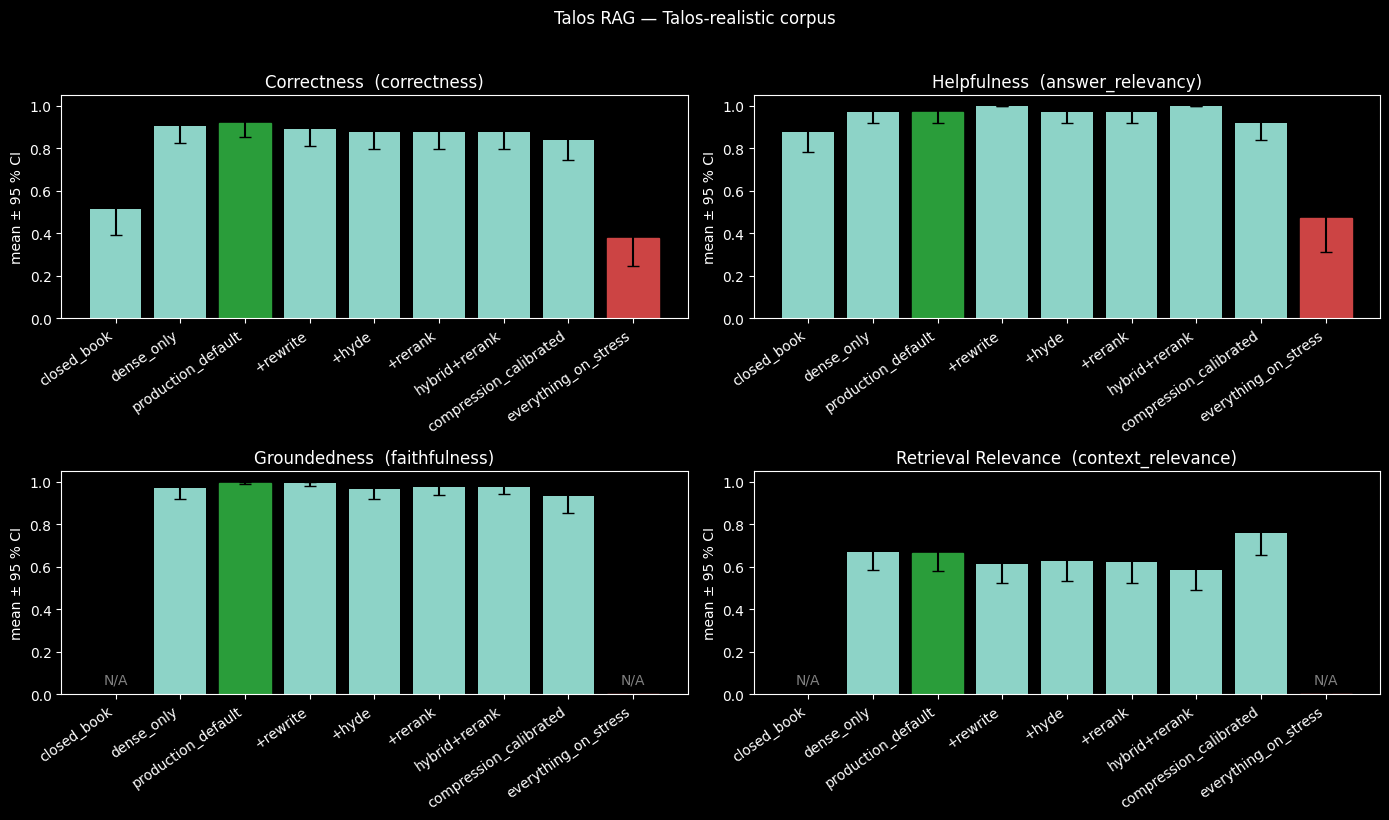

In [13]:
import matplotlib.pyplot as plt
import numpy as np

FRIEND_LABELS = {'correctness': 'Correctness', 'answer_relevancy': 'Helpfulness', 'faithfulness': 'Groundedness', 'context_relevance': 'Retrieval Relevance'}
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()
order = [v.name for v in variants_cfg]
for ax, metric in zip(axes, FRIEND_LABELS):
    sub = summary_df[summary_df.metric == metric].set_index('variant').reindex(order)
    means = sub['mean'].values.astype(float)
    err_lo = np.where(np.isnan(means), 0, means - sub['lo'].values)
    err_hi = np.where(np.isnan(means), 0, sub['hi'].values - means)
    bars = ax.bar(range(len(order)), np.where(np.isnan(means), 0, means), yerr=[err_lo, err_hi], capsize=4)
    for i, name in enumerate(order):
        if name == 'production_default': bars[i].set_color('#2a9d3a')
        elif name == 'everything_on_stress': bars[i].set_color('#c44')
    for i, m in enumerate(means):
        if np.isnan(m): ax.text(i, 0.05, 'N/A', ha='center', color='grey', fontsize=10)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=35, ha='right')
    ax.set_title(f'{FRIEND_LABELS[metric]}  ({metric})')
    ax.set_ylim(0, 1.05); ax.set_ylabel('mean ± 95 % CI')
fig.suptitle('Talos RAG — Talos-realistic corpus', y=1.02)
plt.tight_layout()
plt.savefig(RUN_DIR / 'metrics_e2e.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Counterfactual-noise diagnostic — per category

In [14]:
noise_rows = []
real = e2e_df[e2e_df.variant == BASELINE].set_index('qid')
var = variants[BASELINE]
for q in qa_items:
    if q.qid not in real.index:
        continue
    distractor_ctxs = eu.random_distractor_contexts(
        chunks, set(q.gold_chunk_ids or [q.gold_chunk_id]), k=TOP_K, seed=SEED + hash(q.qid)
    )
    noise_answer = var.answer_with_contexts(q.question, distractor_ctxs)
    noise_correct, _ = eu.judge_correctness(noise_answer, q.answer, q.question, judge)
    real_correct = real.loc[q.qid, 'correctness']
    noise_rows.append({
        'qid': q.qid, 'category': q.category,
        'real_correctness': real_correct,
        'noise_correctness': noise_correct,
        'correctness_drop': real_correct - noise_correct,
    })
noise_df = pd.DataFrame(noise_rows)
noise_df.to_csv(RUN_DIR / 'counterfactual_noise.csv', index=False)
if not noise_df.empty:
    print('Overall:')
    print(f'  Real:  {noise_df["real_correctness"].mean():.3f}')
    print(f'  Noise: {noise_df["noise_correctness"].mean():.3f}')
    print(f'  Drop:  {noise_df["correctness_drop"].mean():.3f}')
    print('\nPer-category:')
    print(noise_df.groupby('category')[['real_correctness','noise_correctness','correctness_drop']].mean().round(3))

Overall:
  Real:  0.919
  Noise: 0.297
  Drop:  0.622

Per-category:
                     real_correctness  noise_correctness  correctness_drop
category                                                                  
multi_hop_abstract              0.850              0.500             0.350
multi_hop_specific              0.944              0.222             0.722
single_hop_specific             0.944              0.222             0.722


## 11 · Closed-book lift — per category

In [15]:
if 'closed_book' in e2e_df.variant.unique():
    cb_full = e2e_df[e2e_df.variant == 'closed_book']
    rows = []
    for vname in [v.name for v in variants_cfg if v.name != 'closed_book']:
        var = e2e_df[e2e_df.variant == vname].set_index(['qid', 'category'])['correctness']
        cbi = cb_full.set_index(['qid', 'category'])['correctness']
        common = var.index.intersection(cbi.index)
        if not len(common):
            continue
        for cat in sorted(set(c for _, c in common)):
            cat_idx = [(q, c) for q, c in common if c == cat]
            rows.append({'variant': vname, 'category': cat, 'lift': round(float((var.loc[cat_idx] - cbi.loc[cat_idx]).mean()), 3)})
        rows.append({'variant': vname, 'category': 'overall', 'lift': round(float((var.loc[common] - cbi.loc[common]).mean()), 3)})
    lift_df = pd.DataFrame(rows)
    lift_df.to_csv(RUN_DIR / 'closed_book_lift.csv', index=False)
    pivot = lift_df.pivot(index='variant', columns='category', values='lift').reindex([v.name for v in variants_cfg if v.name != 'closed_book'])
    pivot

## 12 · 2-judge consistency

In [16]:
if RUN_2JUDGE and alt_judge is not None:
    pd_sub = e2e_df[e2e_df.variant == BASELINE].set_index('qid')
    cal_items = []
    for q in qa_items:
        if q.qid not in pd_sub.index:
            continue
        cal_items.append({'qid': q.qid, 'question': q.question,
                          'answer': pd_sub.loc[q.qid, 'answer'], 'reference': q.answer})
    res2j = eu.two_judge_consistency(cal_items, judge, alt_judge,
                                      metric='correctness', sample_size=10, seed=SEED)
    print(f'2-judge slice on Correctness  (n={res2j["n"]}):')
    print(f'  primary ({JUDGE_MODEL})    mean: {res2j["primary_mean"]:.3f}')
    print(f'  alternative ({ALT_JUDGE_MODEL}) mean: {res2j["alternative_mean"]:.3f}')
    print(f'  Pearson r:  {res2j["pearson"]:.3f}')
    print(f'  Spearman ρ: {res2j["spearman"]:.3f}')
    print(f'  mean |Δ|:   {res2j["mean_abs_disagreement"]:.3f}')
    pd.DataFrame(res2j['rows']).to_csv(RUN_DIR / 'two_judge_consistency.csv', index=False)
else:
    print('2-judge check skipped.')

2-judge slice on Correctness  (n=10):
  primary (gpt-4o-mini)    mean: 0.900
  alternative (gpt-4o) mean: 0.800
  Pearson r:  0.102
  Spearman ρ: 0.102
  mean |Δ|:   0.200


## 13 · Save run manifest

In [17]:
manifest = {
    'eval_version': 'v3-talos',
    'seed': SEED,
    'corpus_folder': str(CORPUS_FOLDER),
    'n_documents': len(docs),
    'n_chunks': len(chunks),
    'n_qa_items': len(qa_items),
    'qa_categories': dict(Counter(q.category for q in qa_items)),
    'top_k': TOP_K, 'beir_k': BEIR_K,
    'generator_model': GENERATOR_MODEL, 'judge_model': JUDGE_MODEL,
    'alt_judge_model': ALT_JUDGE_MODEL if RUN_2JUDGE else None,
    'embedding_model': EMBEDDING_MODEL,
    'variants': [asdict(v) for v in variants_cfg],
    'baseline_for_paired_tests': BASELINE,
    'flags': {'run_2judge': RUN_2JUDGE, 'run_comp_sweep': RUN_COMP_SWEEP, 'export_calibration': EXPORT_CALIBRATION},
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('Wrote', RUN_DIR / 'manifest.json')
for p in sorted(RUN_DIR.iterdir()):
    print(' -', p.name)

Wrote runs_talos/20260428-174442/manifest.json
 - closed_book_lift.csv
 - counterfactual_noise.csv
 - e2e_per_question.csv
 - manifest.json
 - metrics_e2e.png
 - oracle_generation.csv
 - paired_tests.csv
 - retrieval_ir.csv
 - retrieval_ir_summary.csv
 - summary.csv
 - two_judge_consistency.csv


## 14 · How to read these results

Same interpretation rules as `EVAL_REPORT.md` §10:

1. `production_default` is the headline — the configuration we ship.
2. Paired Wilcoxon vs. `production_default`: only `significant == True` rows count.
3. Counterfactual noise drop: large drops ⇒ retrieval is doing real work.
4. Closed-book lift per category: large lift ⇒ retrieval is needed; near-zero lift ⇒ memorisation likely.
5. 2-judge consistency: Pearson > 0.7 validates the cheap judge.

**Special property of this corpus**: the seeded documents (`talos_README.md`, `talos_MCP_CONTRACT.md`) are guaranteed-unseen-by-the-LLM. If the closed-book correctness on those is low while the RAG correctness is high, that's clean evidence retrieval is doing real work — the LLM literally cannot answer without the corpus.